---
title: A Gaussian-process primer — and richer spatial features
subtitle: From a lon/lat interpolator to an ARD GP that weighs elevation, distance-to-coast and slope
short_title: GP primer + features
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-09
keywords:
  - Gaussian process
  - automatic relevance determination
  - spatial covariates
  - elevation
  - distance to coast
abstract: |
  A Gaussian process is a prior over smooth functions — the natural way to say
  the extreme-value parameters vary smoothly across space. We warm up by using a
  GP to interpolate each station's mean annual maximum from its (lon, lat), with
  calibrated uncertainty. Then we ask what a station really "knows": we derive
  physical covariates — elevation, distance to the coast and terrain slope — and
  let an ARD (automatic relevance determination) GP decide, through one
  lengthscale per feature, which of them actually drive the extremes.
---

# A Gaussian-process primer (with `pyrox`)

A **Gaussian process** (GP) is a prior over smooth functions: nearby inputs get
correlated outputs, with the correlation set by a **kernel**. It is the natural
way to say *"the extreme-value parameters vary smoothly across space"*.

As a warm-up, forget extremes for a moment and just use a GP to **interpolate** a
spatial field: regress each station's *mean annual maximum* onto its
`(lon, lat)`, and predict a smooth surface with uncertainty. We use `pyrox.gp`:
a `Matern` kernel, a `GPPrior`, fit its hyperparameters by SVI, then `condition`
on the data and `predict` on a grid. Then we go **beyond `(lon, lat)`** and give
the GP physical features to work with.


In [1]:
import sys
import pathlib

try:
    import spatial_extremes  # noqa: F401  installed editable in the project venv
except ModuleNotFoundError:
    _here = pathlib.Path.cwd().resolve()
    _roots = (_here, *_here.parents)
    _cands = [r / "src" for r in _roots]
    _cands += [r / "projects" / "spatial_extremes" / "src" for r in _roots]
    _src = next((c for c in _cands if (c / "spatial_extremes").exists()), None)
    if _src is None:
        raise RuntimeError("cannot locate spatial_extremes/src") from None
    sys.path.insert(0, str(_src))

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

In [3]:
import numpy as np
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import SVI, Trace_ELBO, autoguide
from pyrox.gp import GPPrior, Matern, gp_factor

from spatial_extremes import data
from spatial_extremes.data import IBERIA_BBOX

maxima, stations, years, is_real = data.load_annual_maxima(min_years=20)
X = jnp.asarray(stations)                 # (S, 2) lon/lat
y = jnp.asarray(np.nanmean(maxima, 1))           # mean annual max per station
# standardise inputs and target for stable GP fitting
Xm, Xs = X.mean(0), X.std(0)
Xn = (X - Xm) / Xs
ym, ysd = float(y.mean()), float(y.std())
yn = (y - ym) / ysd
print("source:", "REAL" if is_real else "SYNTHETIC", "| stations", X.shape[0])

/Users/eman/code_projects/research_notebook/projects/spatial_extremes/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


source: REAL | stations 107


In [4]:
def model(Xn, yn):
    k = Matern(nu=1.5)
    k.set_prior("variance", ndist.LogNormal(0.0, 1.0))
    k.set_prior("lengthscale", ndist.LogNormal(0.0, 1.0))
    noise = numpyro.sample("noise", ndist.LogNormal(np.log(0.2), 0.5))
    gp_factor("obs", GPPrior(kernel=k, X=Xn), yn, noise)

guide = autoguide.AutoNormal(model)
svi = SVI(model, guide, numpyro.optim.Adam(2e-2), Trace_ELBO())
res = svi.run(jr.PRNGKey(0), 5000, Xn, yn, progress_bar=False)


def fitted(name):
    key = next(k for k in res.params if name in k and k.endswith("_auto_loc"))
    return float(jnp.exp(res.params[key]))


var_fit, ls_fit, noise_fit = fitted("variance"), fitted("lengthscale"), fitted("noise")
print(f"fitted kernel: variance={var_fit:.2f}, lengthscale={ls_fit:.2f}, "
      f"noise={noise_fit:.2f}")

fitted kernel: variance=0.85, lengthscale=0.91, noise=0.44


Condition the fitted GP on the stations and predict on a regular grid over Iberia.
(We **learn** the observation noise: with it fixed too small the GP is forced to
interpolate every station and the lengthscale collapses toward zero — a spiky,
overfit surface. Learning it recovers an honest regional lengthscale.)

In [5]:
lon_min, lon_max, lat_min, lat_max = IBERIA_BBOX
glon = np.linspace(lon_min, lon_max, 60)
glat = np.linspace(lat_min, lat_max, 60)
GX, GY = np.meshgrid(glon, glat)
grid = np.stack([GX.ravel(), GY.ravel()], axis=1)
gridn = (jnp.asarray(grid) - Xm) / Xs

k = Matern(nu=1.5, init_variance=var_fit, init_lengthscale=ls_fit)
prior = GPPrior(kernel=k, X=Xn)
with numpyro.handlers.seed(rng_seed=0):
    cond = prior.condition(yn, noise_fit)
    mean, var = cond.predict(gridn)

mean_field = np.asarray(mean) * ysd + ym
std_field = np.sqrt(np.asarray(var)) * ysd

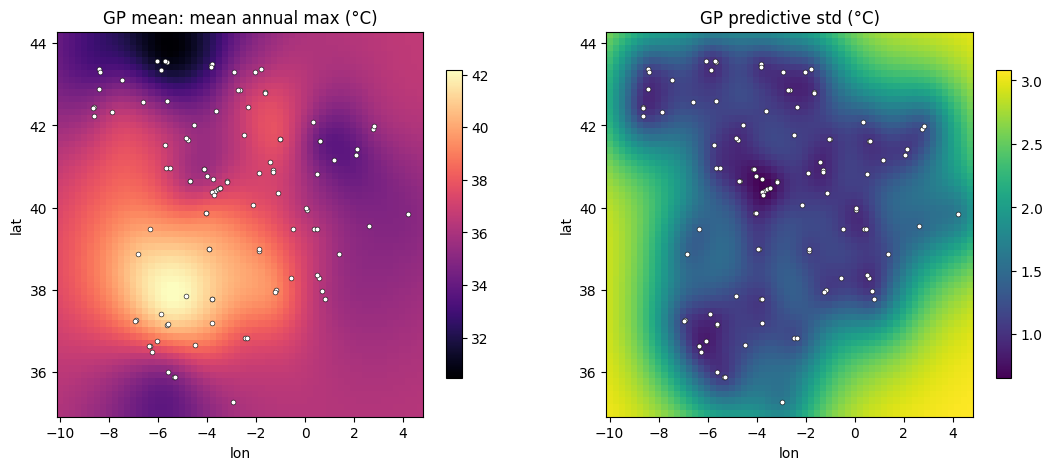

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, field, title, cmap in [
    (axes[0], mean_field, "GP mean: mean annual max (°C)", "magma"),
    (axes[1], std_field, "GP predictive std (°C)", "viridis"),
]:
    pc = ax.pcolormesh(GX, GY, field.reshape(GX.shape), cmap=cmap, shading="auto")
    ax.scatter(stations[:, 0], stations[:, 1], c="w", s=12, edgecolor="k", linewidth=0.4)
    fig.colorbar(pc, ax=ax, shrink=0.8)
    ax.set_title(title)
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
plt.show()

The GP gives a smooth interpolated surface **and** a calibrated uncertainty that
grows away from stations — all from just two inputs, `(lon, lat)`. But a station
"knows" more than where it sits. The rest of the notebook hands the GP **physical
covariates** and lets it decide which ones matter.


## Beyond lon/lat: physical spatial features

Longitude and latitude are only proxies for what actually shapes a station's
summer extremes. Three physical covariates carry real signal:

- **elevation** — temperature falls with height (the lapse rate, ≈ 6.5 °C/km);
- **distance to the coast** — the sea moderates extremes, so inland stations run
  hotter and more variable;
- **terrain slope** — local relief, a proxy for sheltered valleys vs. exposed
  ground.

These are **not** in the CDS archive (which stores only `lon`/`lat`), so we derive
them once from public geodata — a DEM (OpenTopoData) for elevation and slope, the
Natural Earth coastline for distance — and cache a small table. The notebook only
*reads* that cache (`scripts/build_features.py` builds it), so rendering never
touches the network.


feature table: (107, 5)
       elevation  dist_coast_km  slope_deg
count      107.0          107.0      107.0
mean       366.2          106.8        2.0
std        377.5          113.2        2.8
min          0.0            0.0        0.0
25%         26.5            3.3        0.4
50%        242.0           60.7        1.1
75%        648.5          183.5        2.6
max       1758.0          348.1       20.7


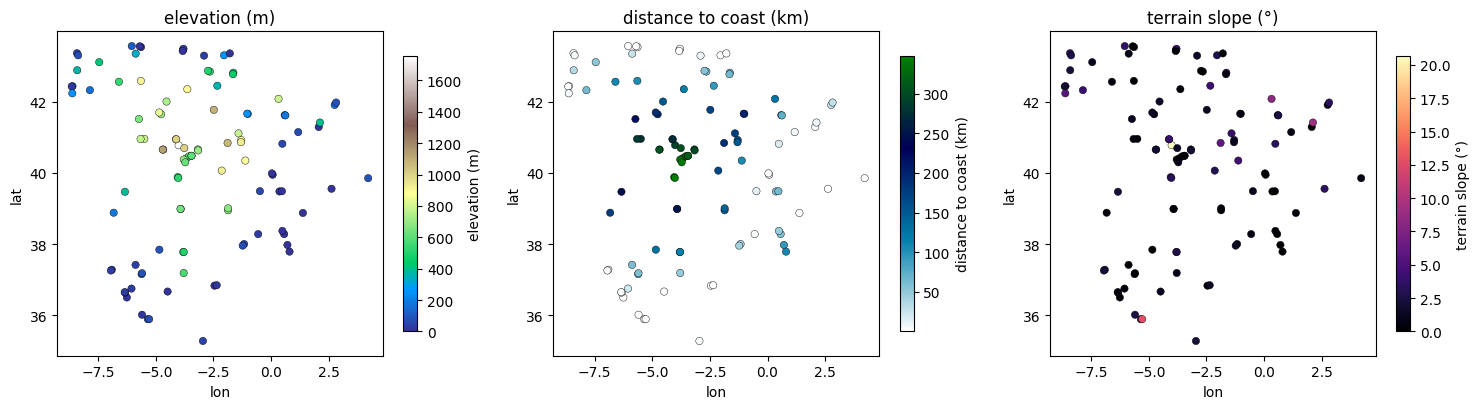

In [7]:
from spatial_extremes.features import load_station_features

feat = load_station_features(stations)
FEATURES = ["lon", "lat", "elevation", "dist_coast_km", "slope_deg"]
FLABELS = {
    "lon": "longitude (°E)", "lat": "latitude (°N)",
    "elevation": "elevation (m)", "dist_coast_km": "distance to coast (km)",
    "slope_deg": "terrain slope (°)",
}
F = feat[FEATURES].to_numpy()
print("feature table:", F.shape)
print(feat[["elevation", "dist_coast_km", "slope_deg"]].describe().round(1).to_string())

# maps of the three derived features
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, cmap in [
    (axes[0], "elevation", "terrain"),
    (axes[1], "dist_coast_km", "ocean_r"),
    (axes[2], "slope_deg", "magma"),
]:
    sc = ax.scatter(feat["lon"], feat["lat"], c=feat[col], cmap=cmap, s=28,
                    edgecolor="k", linewidth=0.3)
    fig.colorbar(sc, ax=ax, shrink=0.85, label=FLABELS[col])
    ax.set_title(FLABELS[col]); ax.set_xlabel("lon"); ax.set_ylabel("lat")
plt.tight_layout(); plt.show()


A quick look before modelling — the Pearson correlation of each feature with the
per-station mean annual maximum. Some of these will surprise us, which is exactly
why we let the GP weigh the features rather than guessing.

In [8]:
ybar_st = np.asarray(y)
print("corr(feature, mean annual max):")
for col in FEATURES:
    r = np.corrcoef(feat[col].to_numpy(), ybar_st)[0, 1]
    print(f"  {FLABELS[col]:24s} r = {r:+.2f}")


corr(feature, mean annual max):
  longitude (°E)           r = -0.04
  latitude (°N)            r = -0.43
  elevation (m)            r = +0.03
  distance to coast (km)   r = +0.24
  terrain slope (°)        r = -0.25


The correlations hold a surprise: **latitude** carries the strongest signal (the
north–south gradient), while raw **elevation** barely correlates with the mean
annual maximum. That is *confounding*, not a non-effect — the lowest-elevation
stations are a mix of cool, sea-moderated coastal sites **and** the hottest inland
valleys, so elevation's influence is masked marginally even though the highest
mountains are plainly the coolest (the 1758 m station tops out near 29 °C). A
multi-feature model is exactly what untangles this.

## ARD: one lengthscale per feature

`pyrox`'s Matérn is **isotropic** — a single lengthscale shared by every input.
**Automatic Relevance Determination (ARD)** gives each input its *own* lengthscale:
a **short** lengthscale means the function changes quickly along that feature (it
*matters*), a **long** one means the GP barely uses it. We implement ARD by scaling
each standardised feature by a learnable per-dimension lengthscale and feeding the
result to the isotropic kernel — so the fitted scales themselves are the relevance
read-out. As above, we **learn the noise**: without it the GP overfits the noisiest
feature (slope) with a vanishing lengthscale and mis-reports its relevance.

In [9]:
# standardise the 5 features and fit a per-dimension (ARD) lengthscale to each
Fm, Fsd = F.mean(0), F.std(0)
Fn = (F - Fm) / Fsd
D = Fn.shape[1]


def ard_model(Fn, yn):
    log_ell = numpyro.sample("log_ell", ndist.Normal(0.0, 1.0).expand([D]).to_event(1))
    ell = jnp.exp(log_ell)
    Xs = Fn / ell                                   # per-dimension (ARD) scaling
    k = Matern(nu=1.5, init_lengthscale=1.0)        # isotropic on the scaled inputs
    k.set_prior("variance", ndist.LogNormal(0.0, 1.0))
    noise = numpyro.sample("noise", ndist.LogNormal(np.log(0.2), 0.5))
    gp_factor("obs", GPPrior(kernel=k, X=Xs), yn, noise)


ard_guide = autoguide.AutoNormal(ard_model)
ard_svi = SVI(ard_model, ard_guide, numpyro.optim.Adam(2e-2), Trace_ELBO())
ard_res = ard_svi.run(jr.PRNGKey(0), 6000, jnp.asarray(Fn), yn, progress_bar=False)


def _fit(res, name):
    key = next(k for k in res.params if name in k and k.endswith("_auto_loc"))
    return np.exp(np.asarray(res.params[key]))


ell = _fit(ard_res, "log_ell")
var_ard = float(_fit(ard_res, "variance"))
noise_ard = float(_fit(ard_res, "noise"))
print("fitted ARD lengthscales (short = relevant):")
for name, l in zip(FEATURES, ell):
    print(f"  {FLABELS[name]:24s} ℓ = {l:5.2f}   relevance 1/ℓ = {1 / l:4.2f}")

fitted ARD lengthscales (short = relevant):
  longitude (°E)           ℓ =  0.78   relevance 1/ℓ = 1.27
  latitude (°N)            ℓ =  0.34   relevance 1/ℓ = 2.93
  elevation (m)            ℓ =  1.21   relevance 1/ℓ = 0.83
  distance to coast (km)   ℓ =  1.15   relevance 1/ℓ = 0.87
  terrain slope (°)        ℓ =  3.02   relevance 1/ℓ = 0.33


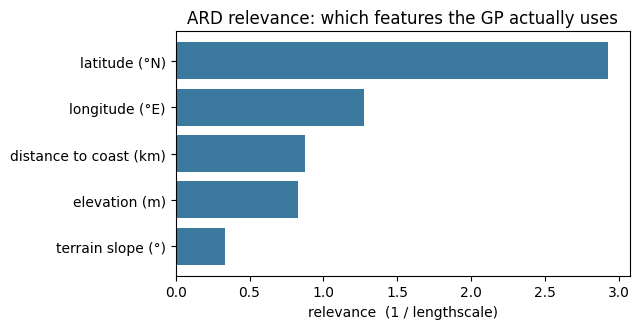

In [10]:
rel = 1.0 / ell
order = np.argsort(rel)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.barh([FLABELS[FEATURES[i]] for i in order], rel[order], color="#3b7a9e")
ax.set_xlabel("relevance  (1 / lengthscale)")
ax.set_title("ARD relevance: which features the GP actually uses")
plt.tight_layout(); plt.show()


## Does it predict better?

Relevance is suggestive; the honest test is **out-of-sample** accuracy. We compare
leave-one-out (LOO) RMSE of the plain `(lon, lat)` GP against the feature-rich ARD
GP, using the closed-form GP-LOO identity (no refitting):
$\;\hat\mu_{-i} = y_i - [K^{-1}y]_i / [K^{-1}]_{ii}$.


In [11]:
def matern32(X1, X2, var, ls):
    d2 = ((X1[:, None, :] - X2[None, :, :]) ** 2).sum(-1)
    r = np.sqrt(np.clip(d2, 1e-30, None)) / ls
    a = np.sqrt(3.0) * r
    return var * (1 + a) * np.exp(-a)


def loo_rmse(Xs, var, ls, noise):
    Xs = np.asarray(Xs)
    K = matern32(Xs, Xs, var, ls) + float(noise) * np.eye(len(Xs))
    Kinv = np.linalg.inv(K)
    yv = np.asarray(yn)
    mu_loo = yv - (Kinv @ yv) / np.diag(Kinv)
    return float(np.sqrt(np.mean((yv - mu_loo) ** 2)) * ysd)


rmse_ll = loo_rmse(Xn, var_fit, ls_fit, noise_fit)        # plain lon/lat GP
rmse_ard = loo_rmse(Fn / ell, var_ard, 1.0, noise_ard)    # feature-rich ARD GP
print(f"LOO RMSE — lon/lat GP      : {rmse_ll:.2f} °C")
print(f"LOO RMSE — ARD feature GP  : {rmse_ard:.2f} °C")
print(f"=> features change LOO error by {100 * (1 - rmse_ard / rmse_ll):+.0f}%")

LOO RMSE — lon/lat GP      : 2.56 °C
LOO RMSE — ARD feature GP  : 2.70 °C
=> features change LOO error by -6%


## A fuller metric: the Cholesky transform

ARD scales each feature independently — a **diagonal** input transform, axis
aligned. The [`tinygp`](https://github.com/dfm/tinygp) library offers a more
general option, `transforms.Cholesky`: a full **lower-triangular** linear map
$L$ applied to the inputs, so the kernel measures a Mahalanobis distance
$\lVert L(x-x')\rVert$. Off-diagonal entries let the GP **rotate and mix**
features (e.g. a "low *and* coastal" direction) rather than only rescale axes.
ARD is the special case where $L$ is diagonal.

`pyrox` has no transform API, but the idea is one line — feed the isotropic
Matérn the transformed inputs $X L^{\top}$ with a learned lower-triangular $L$.
It has $D(D{+}1)/2$ parameters instead of ARD's $D$; the question is whether that
extra freedom **helps or overfits** on ~100 stations.


leave-one-out RMSE, simplest to richest:
  lon/lat GP         : 2.56 °C   (3 params)
  ARD diagonal metric: 2.70 °C   (7 params)
  Cholesky full metric: 2.74 °C  (17 params)


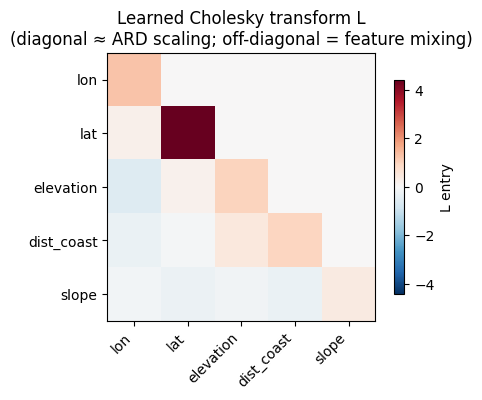

In [12]:
# tinygp-style Cholesky transform: a learned lower-triangular L (positive diagonal),
# generalising ARD's diagonal rescaling to a full Mahalanobis metric ‖L(x-x')‖.
n_off = D * (D - 1) // 2

def chol_model(Fn, yn):
    log_diag = numpyro.sample("log_diag", ndist.Normal(0.0, 1.0).expand([D]).to_event(1))
    off = numpyro.sample("offdiag", ndist.Normal(0.0, 1.0).expand([n_off]).to_event(1))
    L = jnp.zeros((D, D)).at[jnp.arange(D), jnp.arange(D)].set(jnp.exp(log_diag))
    L = L.at[jnp.tril_indices(D, -1)].set(off)
    k = Matern(nu=1.5, init_lengthscale=1.0)
    k.set_prior("variance", ndist.LogNormal(0.0, 1.0))
    noise = numpyro.sample("noise", ndist.LogNormal(np.log(0.2), 0.5))
    gp_factor("obs", GPPrior(kernel=k, X=Fn @ L.T), yn, noise)

chol_guide = autoguide.AutoNormal(chol_model)
chol_svi = SVI(chol_model, chol_guide, numpyro.optim.Adam(2e-2), Trace_ELBO())
chol_res = chol_svi.run(jr.PRNGKey(0), 8000, jnp.asarray(Fn), yn, progress_bar=False)

def _loc(res, name):
    key = next(k for k in res.params if name in k and k.endswith("_auto_loc"))
    return np.asarray(res.params[key])

L = np.zeros((D, D))
L[np.diag_indices(D)] = np.exp(_loc(chol_res, "log_diag"))
L[np.tril_indices(D, -1)] = _loc(chol_res, "offdiag")
var_chol = float(np.exp(_loc(chol_res, "variance")))
noise_chol = float(np.exp(_loc(chol_res, "noise")))
rmse_chol = loo_rmse(np.asarray(Fn) @ L.T, var_chol, 1.0, noise_chol)

print("leave-one-out RMSE, simplest to richest:")
print(f"  lon/lat GP         : {rmse_ll:.2f} °C   (3 params)")
print(f"  ARD diagonal metric: {rmse_ard:.2f} °C   ({D + 2} params)")
print(f"  Cholesky full metric: {rmse_chol:.2f} °C  ({n_off + D + 2} params)")

short = [f.replace("_km", "").replace("_deg", "") for f in FEATURES]
fig, ax = plt.subplots(figsize=(4.8, 4.0))
m = np.abs(L).max()
im = ax.imshow(L, cmap="RdBu_r", vmin=-m, vmax=m)
ax.set_xticks(range(D)); ax.set_yticks(range(D))
ax.set_xticklabels(short, rotation=45, ha="right"); ax.set_yticklabels(short)
fig.colorbar(im, ax=ax, shrink=0.8, label="L entry")
ax.set_title("Learned Cholesky transform L\n(diagonal ≈ ARD scaling; off-diagonal = feature mixing)")
plt.tight_layout(); plt.show()


## Takeaway

Two `(lon, lat)` coordinates already interpolate the mean-annual-max field well,
and — the honest result — **richer inputs do not beat them here.** Leave-one-out
RMSE rises as we add flexibility:

| model | inputs | params | LOO RMSE |
|---|---|---|---|
| `(lon, lat)` GP | 2 | 3 | **2.56 °C** |
| ARD (diagonal metric) | 5 | 7 | 2.70 °C |
| Cholesky (full metric) | 5 | 17 | 2.74 °C |

With a dense network every held-out station has near neighbours, so coordinates
already carry the smooth field; elevation and coastline are largely **redundant
with location** for interpolation, and the Cholesky transform's extra
feature-mixing parameters only **overfit** ~100 stations. More capacity, no better
generalisation — the bias–variance trade-off in one table.

What the features still buy is **diagnosis and reach**, not a lower interpolation
error:

- **ARD as a relevance read-out.** The fitted lengthscales rank **latitude** first
  (the north–south gradient), longitude / distance-to-coast / elevation in the
  middle, and **terrain slope last** — the GP rightly distrusts a noisy, local
  feature *once the observation noise is learned*. (Fixed-noise fits invert this,
  overfitting slope with a vanishing lengthscale.)
- **Extrapolation and covariates.** Where stations are sparse a `(lon, lat)` GP
  reverts to the prior mean, while elevation and coast distance still inform the
  field — which is why the spatial-GEV capstones can take them as covariates on
  $\mu(s)$ rather than leaning on coordinates alone.

**Next:** instead of interpolating a precomputed summary, we put a GP *inside* the
GEV model so the location parameter $\mu(s)$ is a latent spatial field learned
jointly with the tail — and these same covariates can drive it.
